# Atividade curta: do problema real a `X` e `y`

**Contexto:** a coordenação quer estudar o risco de atraso na entrega de atividades.

Cada linha representa **um aluno em uma semana**. Os atributos disponíveis são frequência, média parcial e quantidade de atividades já entregues. O rótulo informa se houve atraso na atividade seguinte.

Ao final, você deverá saber representar os dados com NumPy e pandas e separar atributos (`X`) e alvo (`y`).


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Dados em NumPy

Os dados abaixo são fictícios e pequenos para permitir a inspeção manual. As colunas estão nesta ordem:

`frequencia`, `media_parcial`, `atividades_entregues`, `atrasou_proxima_atividade`.


In [6]:
dados = np.array([
    [92, 8.5, 5, 0],
    [75, 6.0, 3, 1],
    [88, 7.2, 4, 0],
    [60, 4.8, 2, 1],
    [95, 9.1, 5, 0],
    [70, 5.5, 3, 1],
    [82, 7.0, 4, 0],
    [65, 5.0, 2, 1],
])

print(dados)
print("Formato do array:", dados.shape)


[[92.   8.5  5.   0. ]
 [75.   6.   3.   1. ]
 [88.   7.2  4.   0. ]
 [60.   4.8  2.   1. ]
 [95.   9.1  5.   0. ]
 [70.   5.5  3.   1. ]
 [82.   7.   4.   0. ]
 [65.   5.   2.   1. ]]
Formato do array: (8, 4)


In [7]:
# Mostre quantos exemplos e quantas colunas existem no array.
# Depois, mostre apenas a primeira linha para identificar uma observação.
num_exemplos, num_colunas = dados.shape
print(f"Número de exemplos: {num_exemplos}")
print(f"Número de colunas: {num_colunas}")
print("\nPrimeira linha (observação):")
print(dados[0])



Número de exemplos: 8
Número de colunas: 4

Primeira linha (observação):
[92.   8.5  5.   0. ]


## 2. Conversão para pandas

Um DataFrame associa nomes às colunas e facilita a leitura e a seleção dos dados.


In [8]:
colunas = [
    "frequencia",
    "media_parcial",
    "atividades_entregues",
    "atrasou_proxima_atividade",
]

df = pd.DataFrame(dados, columns=colunas)
df


,frequencia,media_parcial,atividades_entregues,atrasou_proxima_atividade
0,92.0,8.5,5.0,0.0
1,75.0,6.0,3.0,1.0
2,88.0,7.2,4.0,0.0
3,60.0,4.8,2.0,1.0
4,95.0,9.1,5.0,0.0
5,70.0,5.5,3.0,1.0
6,82.0,7.0,4.0,0.0
7,65.0,5.0,2.0,1.0


In [9]:
# Use head(), shape e dtypes para inspecionar o DataFrame.
# Em seguida, verifique se existem valores ausentes.
print("Primeiras linhas:")
print(df.head())
print("\nFormato do DataFrame:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores ausentes:")
print(df.isnull().sum())



Primeiras linhas:
   frequencia  media_parcial  atividades_entregues  atrasou_proxima_atividade
0        92.0            8.5                   5.0                        0.0
1        75.0            6.0                   3.0                        1.0
2        88.0            7.2                   4.0                        0.0
3        60.0            4.8                   2.0                        1.0
4        95.0            9.1                   5.0                        0.0

Formato do DataFrame: (8, 4)

Tipos de dados:
frequencia                   float64
media_parcial                float64
atividades_entregues         float64
atrasou_proxima_atividade    float64
dtype: object

Valores ausentes:
frequencia                   0
media_parcial                0
atividades_entregues         0
atrasou_proxima_atividade    0
dtype: int64


## 3. Separação em `X` e `y`

- `X`: matriz contendo somente os atributos usados como entrada.
- `y`: vetor contendo o rótulo que se deseja prever.
- O rótulo **não pode permanecer dentro de `X`**, pois isso causaria vazamento da resposta.


In [10]:
# Crie X com frequencia, media_parcial e atividades_entregues.
# Crie y com atrasou_proxima_atividade.
# Mostre X, y e seus respectivos formatos.
X = df[["frequencia", "media_parcial", "atividades_entregues"]].values
y = df["atrasou_proxima_atividade"].values

print("Matriz X (atributos):")
print(X)
print("\nFormato de X:", X.shape)
print("\nVetor y (rótulo):")
print(y)
print("\nFormato de y:", y.shape)



Matriz X (atributos):
[[92.   8.5  5. ]
 [75.   6.   3. ]
 [88.   7.2  4. ]
 [60.   4.8  2. ]
 [95.   9.1  5. ]
 [70.   5.5  3. ]
 [82.   7.   4. ]
 [65.   5.   2. ]]

Formato de X: (8, 3)

Vetor y (rótulo):
[0. 1. 0. 1. 0. 1. 0. 1.]

Formato de y: (8,)


## 4. Visualização rápida

Construa um gráfico de barras com a quantidade de exemplos de cada classe de `y`. Use os rótulos **Não atrasou** para 0 e **Atrasou** para 1.


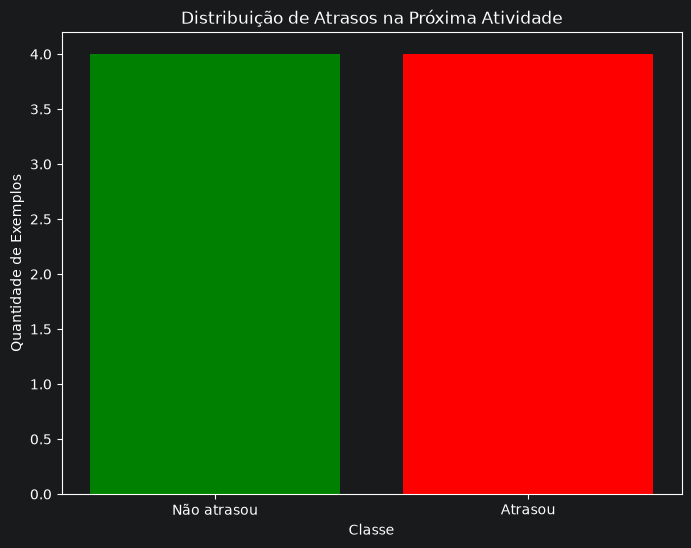

In [11]:
# Conte os valores de y e construa o gráfico solicitado.
# Inclua título e nomes nos eixos.
contagem = pd.Series(y).value_counts().sort_index()
rotulos = ["Não atrasou", "Atrasou"]

plt.figure(figsize=(8, 6))
plt.bar(rotulos, contagem.values, color=['green', 'red'])
plt.title("Distribuição de Atrasos na Próxima Atividade")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Exemplos")
plt.show()



## 5. Interpretação

Responda em uma célula Markdown:

1. Qual é a unidade de análise?
2. Quantos exemplos e atributos existem?
3. Qual é o rótulo?
4. O problema é supervisionado? Por quê?
5. Cite uma limitação ou risco dessa formulação.


**Resposta do aluno:**

1. 
2. 
3. 
4. 
5. 
